# The Price is Right

## Week 8 Order of Play

Day 1: Modal.com and SpecialistAgent  
Day 2: RAG, FrontierAgent, Ensemble Agent  
Day 3: ScannerAgent, MessengerAgent  
Day 4: AutonomousPlannerAgent and DealAgentFramework  
Day 5: The Price Is Right Finale

## RAG (Retrieval Augmented Generation) based on a dataset of 800,000 scraped Amazon products

#### For our 2nd agent, we will be asking OpenAI to estimate the price of one of our deals - and we will give it a hand.

We discovered that LLMs are really good at this, out of the box.

And we discovered that we can beat a frontier LLM by fine-tuning an open-source LLM.

Now we are going to try **inference time** techniques instead of training -- by using RAG!

In [1]:
# imports

import os
import logging
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import re
import transformers.utils.import_utils as transformers_import_utils

# This notebook only needs text embeddings; skip a broken optional torchvision import.
transformers_import_utils._torchvision_available = False
from sentence_transformers import SentenceTransformer
import chromadb
from sklearn.manifold import TSNE
import plotly.graph_objects as go
from litellm import completion
from tqdm.notebook import tqdm
from agents.evaluator import evaluate
from agents.items import Item

In [2]:
# environment

load_dotenv(override=True)
DB = "products_vectorstore"

In [3]:
# Log in to HuggingFace
# If you don't have a HuggingFace account, you can set one up for free at www.huggingface.co
# And then add the HF_TOKEN to your .env file as explained in the project README

hf_token = os.environ['HF_TOKEN']
login(token=hf_token, add_to_git_credential=False)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
LITE_MODE = False

In [5]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


# Now create a Chroma Datastore

Now we will use the free, open-source Vector database Chroma.  
We will create a Chroma datastore with 400,000 products from our training dataset.

In [6]:
client = chromadb.PersistentClient(path=DB)

# Introducing the SentenceTransformer Encoding LLM

The all-MiniLM is a very useful model from HuggingFace that maps sentences & paragraphs to 384 dimensional vectors and is ideal for tasks like semantic search.

https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

It can run pretty quickly locally.

As an alternative, OpenAI provides a closed-source Embeddings model. Benefits compared to OpenAI embeddings:
1. It's free and fast!
3. We can run it locally, so the data never leaves our box - might be useful if you're building a personal RAG

In [7]:
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [8]:
# Pass in a list of texts, get back a numpy array of vectors

vector = encoder.encode(["A proficient AI engineer who has almost reached the finale of AI Engineering Core Track!"])[0]
print(vector.shape)
vector

(384,)


array([-5.68233766e-02, -6.70465901e-02,  4.41129245e-02,  5.98604698e-03,
       -2.28948686e-02, -2.95300446e-02,  5.56368902e-02,  3.42665426e-02,
       -1.08529374e-01, -3.81690338e-02, -7.43872225e-02, -1.03664272e-01,
        1.69148203e-02,  1.33930321e-03, -6.86191097e-02,  8.99353623e-02,
       -1.45186232e-02, -2.43885294e-02,  4.21855459e-03, -9.62992534e-02,
       -2.51799393e-02,  4.60676290e-02,  4.95346263e-03, -3.88679840e-02,
        1.07717502e-03,  6.82337433e-02, -1.13860350e-02, -5.83416447e-02,
       -1.03801610e-02, -1.74952988e-02, -1.86478570e-02,  4.07059910e-03,
        1.59438048e-02,  6.49721995e-02,  3.71176079e-02,  2.78224312e-02,
       -4.41945456e-02, -2.34372132e-02,  9.71036032e-02, -5.06138951e-02,
       -1.93863995e-02, -3.83471958e-02,  4.76066545e-02, -3.36106978e-02,
        5.08288145e-02,  3.57935131e-02,  2.91818311e-03, -1.06529102e-01,
        4.07211669e-02, -5.85408940e-04, -1.05607413e-01, -1.03584394e-01,
        3.71124074e-02, -

## With that background, let's populate our Chroma database

### By calculating vectors for 800,000 scraped products

This takes 30 minutes on my machine on my GPU - it might take longer for you - feel free to use the Lite dataset!

In [9]:
# Check if the collection exists; if not, create it

collection_name = "products"
existing_collection_names = [collection.name for collection in client.list_collections()]

if collection_name not in existing_collection_names:
    collection = client.create_collection(collection_name)
    for i in tqdm(range(0, len(train), 1000)):
        documents = [item.summary for item in train[i: i+1000]]
        vectors = encoder.encode(documents).astype(float).tolist()
        metadatas = [{"category": item.category, "price": item.price} for item in train[i: i+1000]]
        ids = [f"doc_{j}" for j in range(i, i+1000)]
        ids = ids[:len(documents)]
        collection.add(ids=ids, documents=documents, embeddings=vectors, metadatas=metadatas)

collection = client.get_or_create_collection(collection_name)

  0%|          | 0/800 [00:00<?, ?it/s]

# Let's visualize the vectorized data

In [10]:
# It is very fun turning this up to 800_000 and seeing the full dataset visualized,
# but it almost crashes my box every time so do that at your own risk!! 10_000 is safe!

MAXIMUM_DATAPOINTS = 10_000

In [11]:
CATEGORIES = ['Appliances', 'Automotive', 'Cell_Phones_and_Accessories', 'Electronics','Musical_Instruments', 'Office_Products', 'Tools_and_Home_Improvement', 'Toys_and_Games']
COLORS = ['cyan', 'blue', 'brown', 'orange', 'yellow', 'green' , 'purple', 'red']

In [12]:
# Prework
result = collection.get(include=['embeddings', 'documents', 'metadatas'], limit=MAXIMUM_DATAPOINTS)
vectors = np.array(result['embeddings'])
documents = result['documents']
categories = [metadata['category'] for metadata in result['metadatas']]
colors = [COLORS[CATEGORIES.index(c)] for c in categories]

In [13]:
# Let's try a 2D chart
# TSNE stands for t-distributed Stochastic Neighbor Embedding - it's a common technique for reducing dimensionality of data

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

In [14]:
# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=4, color=colors, opacity=0.7),
    text=[f"Category: {c}<br>Text: {d[:50]}..." for c, d in zip(categories, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='2D Chroma Vectorstore Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y'),
    width=1200,
    height=800,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

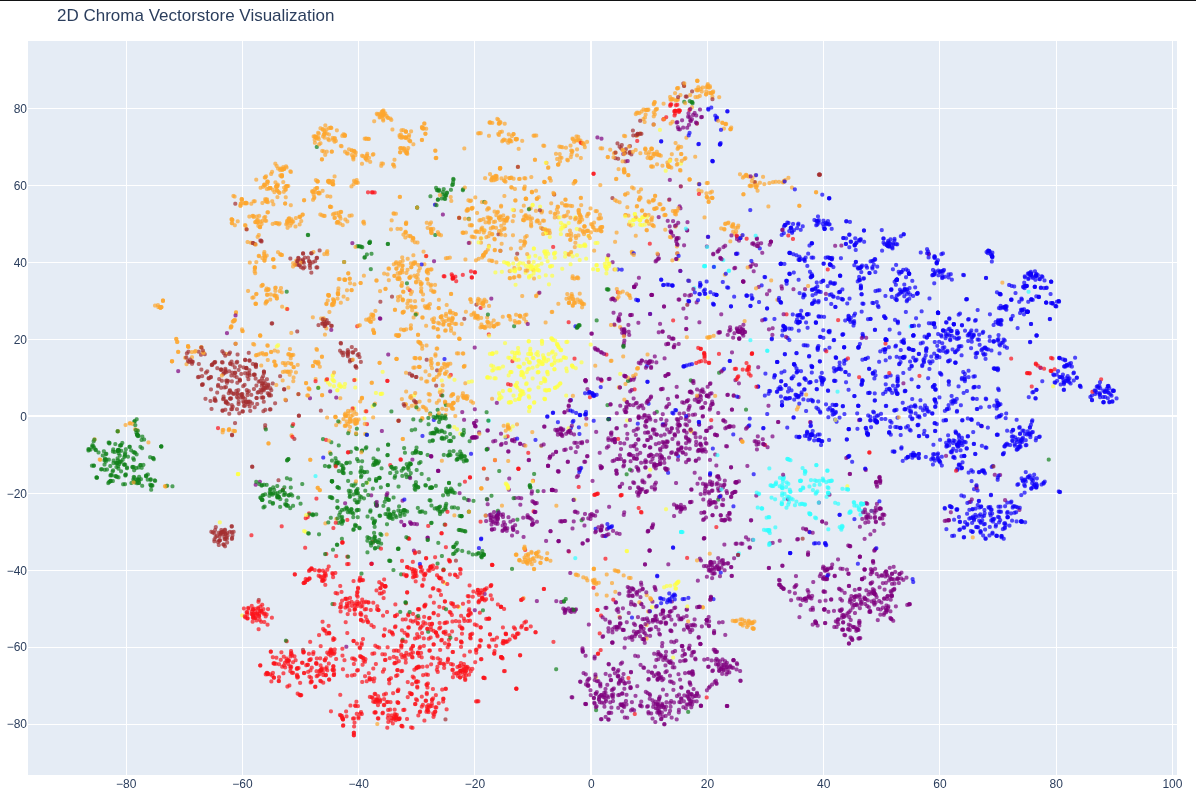

In [15]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

In [16]:
# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=2, color=colors, opacity=0.7),
    text=[f"Category: {c}<br>Text: {d[:50]}..." for c, d in zip(categories, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=1200,
    height=800,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

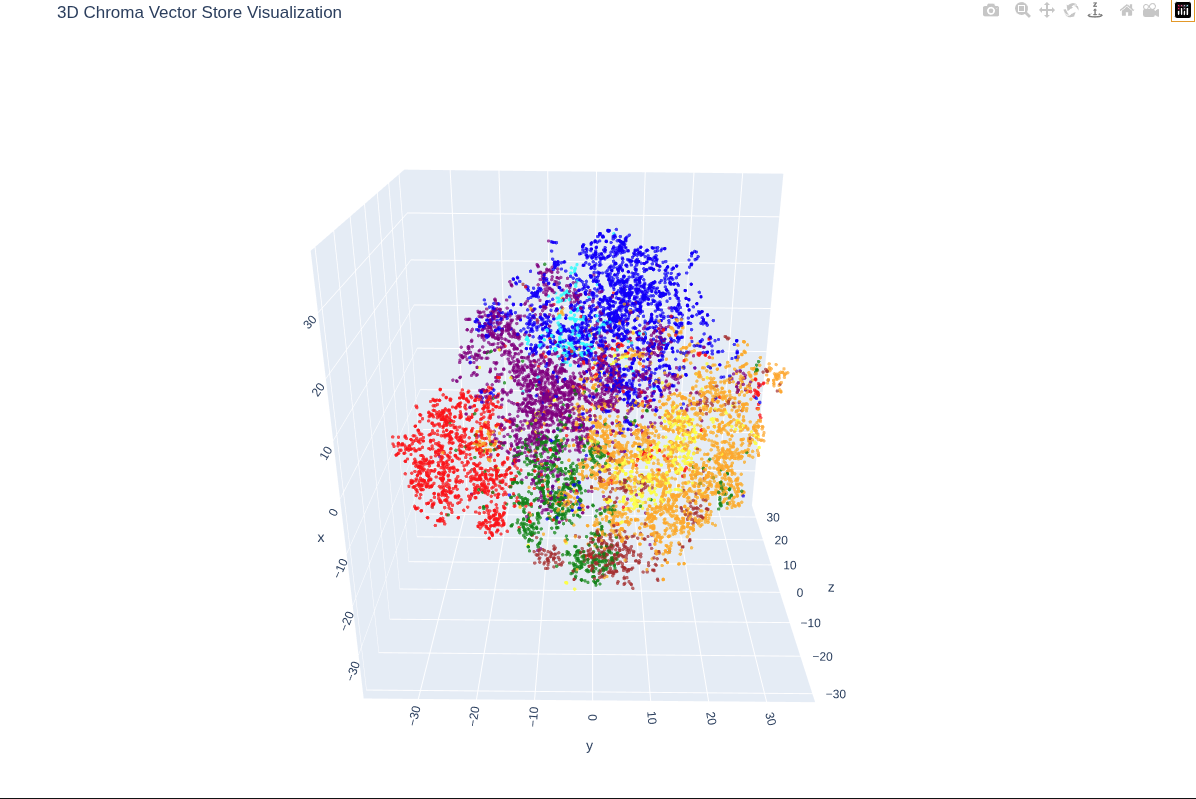

In [17]:
test[0]

<Old Blood Noise Excess V2 Distortion Chorus/Delay Pedal = $219.0>

In [18]:
def vector(item):
    return encoder.encode(item.summary)

In [19]:
def find_similars(item):
    vec = vector(item)
    results = collection.query(query_embeddings=vec.astype(float).tolist(), n_results=5)
    documents = results['documents'][0][:]
    prices = [m['price'] for m in results['metadatas'][0][:]]
    return documents, prices

In [20]:
find_similars(test[0])

(['Title: Old Blood Noise Endeavors Procession Reverb  \nCategory: Audio Effects  \nBrand: Old Blood Noise Endeavors  \nDescription: A compact, sci‑fi inspired reverb pedal with three modulation modes for creating otherworldly echo effects.  \nDetails: Features adjustable mix, decay, speed, depth, and footswitches for bypass and hold; powered by 9\u202fV DC with 60\u202fmA draw.',
  'Title: Boss MD‑2 Mega Distortion Modulation Multi‑Effects Pedal  \nCategory: Music Equipment → Effects Pedals  \nBrand: Boss  \nDescription: A powerful distortion pedal that delivers extreme low‑end crunch and endless sustain for metal and hard rock.  \nDetails: Features a Gain Boost circuit, bottom‑heavy Bottom control for 6/7‑string guitars, adjustable Tone knob, and 1\u202fMΩ input impedance.',
  'Title: Old Blood Noise Endeavors Mondegreen Delay Pedal  \nCategory: Musical Instruments / Effects Pedals  \nBrand: Old Blood Noise  \nDescription: A digital delay pedal that transforms your signal into creati

In [21]:
# We need to give some context to GPT-5.1 by selecting 5 products with similar descriptions

def make_context(similars, prices):
    message = "For context, here are some other items that might be similar to the item you need to estimate.\n\n"
    for similar, price in zip(similars, prices):
        message += f"Potentially related product:\n{similar}\nPrice is ${price:.2f}\n\n"
    return message

In [22]:
documents, prices = find_similars(test[0])
print(make_context(documents, prices))

For context, here are some other items that might be similar to the item you need to estimate.

Potentially related product:
Title: Old Blood Noise Endeavors Procession Reverb  
Category: Audio Effects  
Brand: Old Blood Noise Endeavors  
Description: A compact, sci‑fi inspired reverb pedal with three modulation modes for creating otherworldly echo effects.  
Details: Features adjustable mix, decay, speed, depth, and footswitches for bypass and hold; powered by 9 V DC with 60 mA draw.
Price is $209.00

Potentially related product:
Title: Boss MD‑2 Mega Distortion Modulation Multi‑Effects Pedal  
Category: Music Equipment → Effects Pedals  
Brand: Boss  
Description: A powerful distortion pedal that delivers extreme low‑end crunch and endless sustain for metal and hard rock.  
Details: Features a Gain Boost circuit, bottom‑heavy Bottom control for 6/7‑string guitars, adjustable Tone knob, and 1 MΩ input impedance.
Price is $109.99

Potentially related product:
Title: Old Blood Noise End

In [23]:
def messages_for(item, similars, prices):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}\n\n"
    message += make_context(similars, prices)
    return [{"role": "user", "content": message}]

In [24]:
documents, prices = find_similars(test[0])
print(messages_for(test[0], documents, prices)[0]['content'])

Estimate the price of this product. Respond with the price, no explanation

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.

For context, here are some other items that might be similar to the item you need to estimate.

Potentially related product:
Title: Old Blood Noise Endeavors Procession Reverb  
Category: Audio Effects  
Brand: Old Blood Noise Endeavors  
Description: A compact, sci‑fi inspired reverb pedal with three modulation modes for creating otherworldly echo effects.  
Details: Features adjustable mix, decay, speed, depth, and footswitches for bypass and hold; powered by 9 V 

In [25]:
# The function for gpt-5-mini

def gpt_5__1_rag(item):
    documents, prices = find_similars(item)
    response = completion(model="gpt-5.1", messages=messages_for(item, documents, prices), reasoning_effort="none", seed=42)
    return response.choices[0].message.content

In [26]:
# How much does our favorite distortion pedal cost?

test[0].price

219.0

In [27]:
# Let's do this!!

gpt_5__1_rag(test[0])

'$229.00'

In [28]:
evaluate(gpt_5__1_rag, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$10 $24 $20 $23 $10 $130 $21 $1 $8 $45 $43 $90 $0 $6 $9 $3 $11 $30 $43 $0 $49 $11 $15 $15 $72 $193 $95 $3 $106 $52 $4 $5 $0 $15 $15 $50 $55 $31 $54 $12 $60 $10 $0 $5 $70 $5 $24 $1 $81 $11 $6 $10 $160 $3 $32 $39 $23 $35 $87 $3 $117 $35 $4 $60 $99 $10 $50 $216 $0 $19 $13 $13 $0 $1 $22 $14 $15 $3 $8 $1 $20 $1 $0 $35 $12 $5 $58 $11 $101 $8 $8 $15 $4 $5 $0 $38 $6 $57 $60 $145 $0 $13 $2 $10 $14 $3 $5 $280 $5 $119 $10 $13 $1 $40 $24 $0 $6 $5 $64 $86 $1 $41 $4 $4 $0 $64 $6 $21 $10 $19 $0 $33 $5 $1 $65 $0 $85 $20 $47 $11 $22 $49 $0 $10 $5 $11 $0 $79 $25 $5 $4 $12 $3 $20 $0 $7 $36 $4 $10 $2 $40 $14 $18 $1 $91 $2 $201 $15 $0 $2 $30 $3 $90 $7 $28 $21 $1 $30 $56 $9 $59 $15 $150 $17 $20 $17 $43 $12 $20 $2 $10 $6 $5 $21 $0 $0 $21 $5 $1 $6 

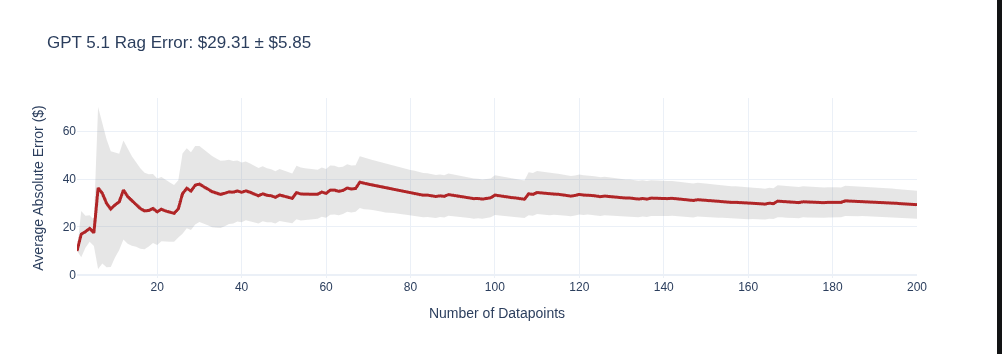

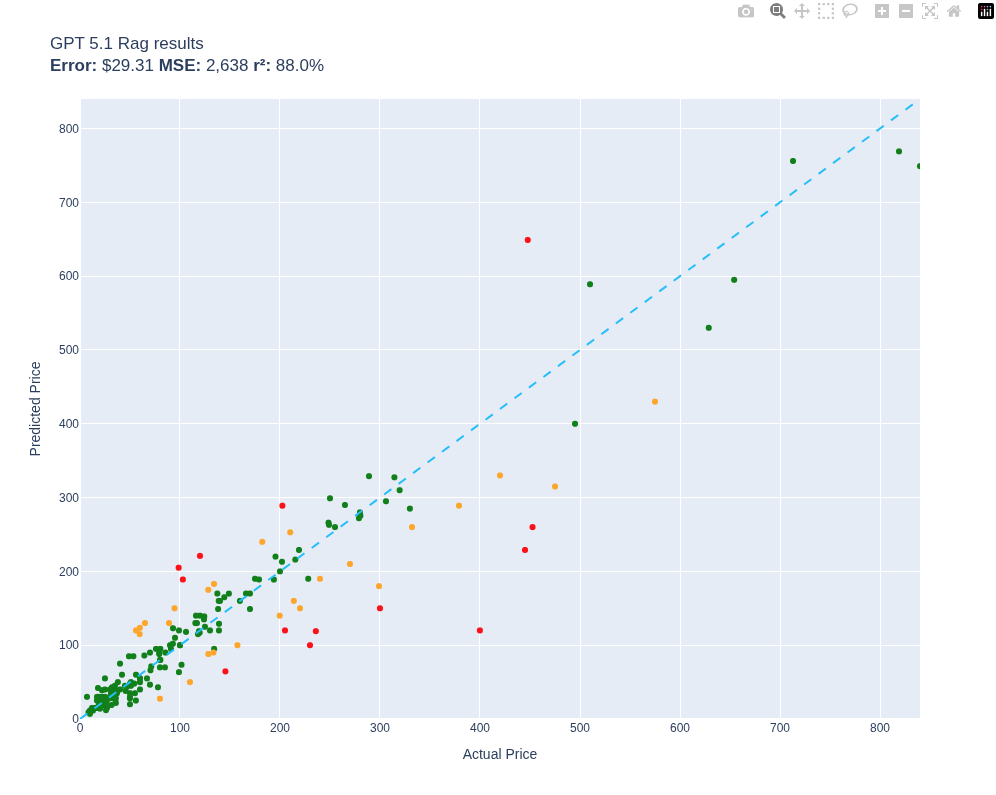

In [29]:
import modal
Pricer = modal.Cls.from_name("pricer-service", "Pricer")
pricer = Pricer()

In [30]:
def specialist(item):
    return pricer.price.remote(item.summary)


In [31]:
def get_price(reply):
    reply = reply.replace("$", "").replace(",", "")
    match = re.search(r"[-+]?\d*\.\d+|\d+", reply)
    return float(match.group()) if match else 0

## Download the Neural Network weights from Week 6 into this directory

The file `deep_neural_network.pth` here:

https://drive.google.com/drive/folders/1uq5C9edPIZ1973dArZiEO-VE13F7m8MK?usp=drive_link

In [32]:

from agents.deep_neural_network import DeepNeuralNetworkInference

runner = DeepNeuralNetworkInference()
runner.setup()
runner.load("deep_neural_network.pth")

def deep_neural_network(item):
    return runner.inference(item.summary)

In [33]:
def ensemble(item):
    price1 = get_price(gpt_5__1_rag(item))
    price2 = specialist(item)
    price3 = deep_neural_network(item)
    return price1 * 0.8 + price2 * 0.1 + price3 * 0.1


In [34]:
evaluate(ensemble, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$14 $32 $19 $15 $10 $130 $6 $3 $7 $46 $48 $85 $1 $5 $7 $2 $15 $28 $37 $31 $34 $10 $14 $28 $77 $192 $114 $0 $110 $52 $2 $6 $8 $5 $13 $70 $49 $30 $54 $8 $71 $16 $1 $12 $78 $6 $21 $1 $89 $5 $7 $19 $171 $9 $33 $30 $22 $38 $83 $6 $126 $36 $2 $56 $156 $12 $44 $238 $0 $24 $13 $12 $12 $4 $20 $13 $13 $3 $7 $0 $6 $5 $1 $39 $11 $1 $62 $13 $75 $4 $7 $11 $3 $5 $2 $36 $5 $45 $50 $159 $1 $5 $1 $17 $10 $13 $2 $278 $6 $105 $13 $10 $0 $41 $17 $5 $3 $12 $60 $80 $1 $59 $2 $3 $4 $59 $5 $29 $2 $26 $3 $28 $5 $1 $62 $0 $77 $15 $49 $4 $21 $27 $4 $13 $5 $13 $1 $11 $11 $6 $3 $20 $4 $9 $1 $27 $41 $3 $18 $3 $70 $14 $12 $1 $130 $2 $178 $16 $1 $3 $32 $2 $130 $16 $28 $17 $2 $27 $38 $9 $43 $12 $114 $13 $17 $16 $50 $9 $20 $0 $9 $5 $3 $20 $1 $6 $22 $2 $6 $7 

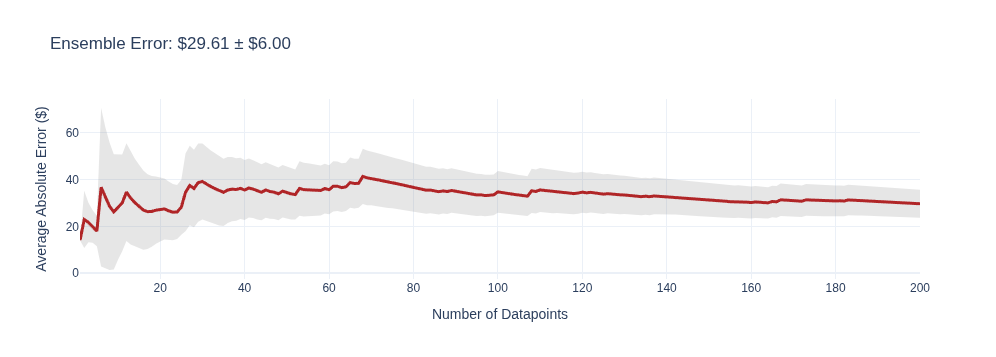

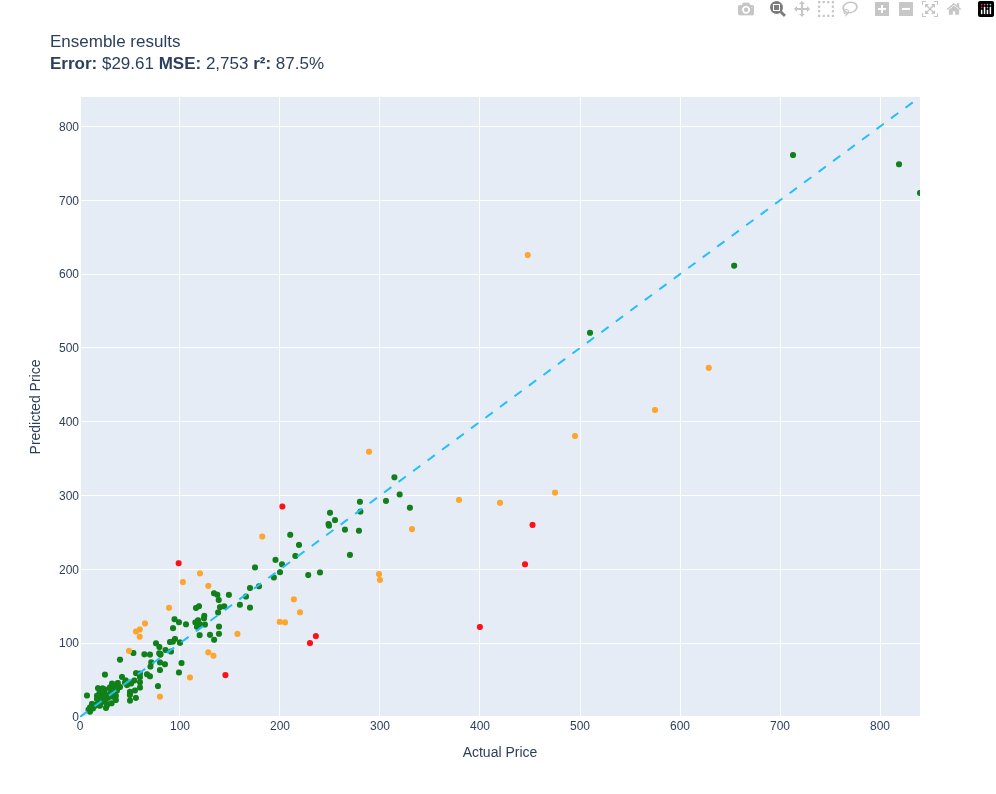

In [35]:
root = logging.getLogger()
root.setLevel(logging.INFO)

In [36]:
from agents.frontier_agent import FrontierAgent

agent = FrontierAgent(collection)
agent.price("Quadcast HyperX condenser mic, connects via usb-c to your computer for crystal clear audio")

INFO:root:[Frontier Agent] Initializing Frontier Agent
INFO:root:[Frontier Agent] Frontier Agent is setting up with OpenAI
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:root:[Frontier Agent] Frontier Agent is ready
INFO:root:[Frontier Agent] Frontier Agent is performing a RAG search of the Chroma datastore to find 5 similar products


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[Frontier Agent] Frontier Agent has found similar products
INFO:root:[Frontier Agent] Frontier Agent is about to call gpt-5.1 with context including 5 similar products
INFO:root:[Frontier Agent] Frontier Agent completed - predicting $135.00


135.0

In [37]:
agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs")

INFO:root:[Frontier Agent] Frontier Agent is performing a RAG search of the Chroma datastore to find 5 similar products


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[Frontier Agent] Frontier Agent has found similar products
INFO:root:[Frontier Agent] Frontier Agent is about to call gpt-5.1 with context including 5 similar products
INFO:root:[Frontier Agent] Frontier Agent completed - predicting $279.00


279.0

In [38]:
from agents.neural_network_agent import NeuralNetworkAgent
agent = NeuralNetworkAgent()


INFO:root:[Neural Network Agent] Neural Network Agent is initializing
INFO:root:Neural Network is using cpu
INFO:root:[Neural Network Agent] Neural Network Agent is ready and weights are loaded


In [39]:
agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs")

INFO:root:[Neural Network Agent] Neural Network Agent is starting a prediction
INFO:root:[Neural Network Agent] Neural Network Agent completed - predicting $162.39


162.39224243164062

In [40]:
from agents.ensemble_agent import EnsembleAgent
agent = EnsembleAgent(collection)

INFO:root:[Ensemble Agent] Initializing Ensemble Agent
INFO:root:[Specialist Agent] Specialist Agent is initializing - connecting to modal
INFO:root:[Frontier Agent] Initializing Frontier Agent
INFO:root:[Frontier Agent] Frontier Agent is setting up with OpenAI
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:root:[Frontier Agent] Frontier Agent is ready
INFO:root:[Neural Network Agent] Neural Network Agent is initializing
INFO:root:Neural Network is using cpu
INFO:root:[Neural Network Agent] Neural Network Agent is ready and weights are loaded
INFO:root:[Ensemble Agent] Ensemble Agent is ready


In [41]:
agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs")

INFO:root:[Ensemble Agent] Running Ensemble Agent - preprocessing text
17:01:32 - LiteLLM:INFO: utils.py:3421 - 
LiteLLM completion() model= llama3.2; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= llama3.2; provider = ollama
17:01:36 - LiteLLM:INFO: utils.py:1302 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
INFO:root:[Ensemble Agent] Pre-processed text using ollama/llama3.2
INFO:root:[Specialist Agent] Specialist Agent is calling remote fine-tuned model
INFO:root:[Specialist Agent] Specialist Agent completed - predicting $299.00
INFO:root:[Frontier Agent] Frontier Agent is performing a RAG search of the Chroma datastore to find 5 similar products


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[Frontier Agent] Frontier Agent has found similar products
INFO:root:[Frontier Agent] Frontier Agent is about to call gpt-5.1 with context including 5 similar products
INFO:root:[Frontier Agent] Frontier Agent completed - predicting $230.00
INFO:root:[Neural Network Agent] Neural Network Agent is starting a prediction
INFO:root:[Neural Network Agent] Neural Network Agent completed - predicting $93.93
INFO:root:[Ensemble Agent] Ensemble Agent complete - returning $223.29


223.29303512573242